<a href="https://colab.research.google.com/github/Anees31-AI/Anees31-AI/blob/main/ch_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784',version=1)

print(mnist.keys())


dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [3]:
X,y=mnist['data'],mnist['target']
X.shape


(70000, 784)

In [4]:
y.shape

(70000,)

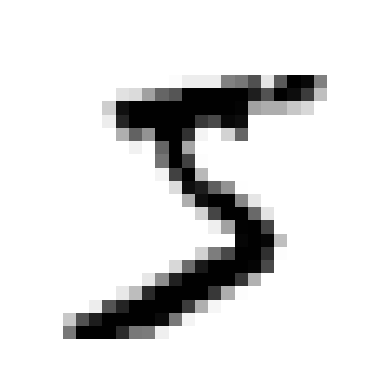

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

#Load dataset
mnist=fetch_openml('mnist_784',version=1)
X,y=mnist.data,mnist.target
#Use iloc to get the first digit
some_digit=X.iloc[0]
some_digit_image=some_digit.to_numpy().reshape(28,28)

plt.imshow(some_digit_image,cmap=mpl.cm.binary,interpolation="nearest")
plt.axis("off")
plt.show()

In [6]:
y[0]

'5'

In [7]:
import numpy as np
y=y.astype(np.uint8)


In [8]:
X_train,X_test,y_train,y_test=X[:60000],X[60000:],y[:60000],y[60000:]

In [9]:
y_train_5=(y_train==5) #True for all 5s ,false for all other digits
y_test_5=(y_test==5)

In [10]:
from sklearn.linear_model import SGDClassifier
sgd_clf=SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train)
sgd_clf.predict([some_digit])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([3], dtype=uint8)

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
import numpy as np

# Setup cross-validation
skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for train_index, test_index in skfolds.split(X_train, y_train):
    clone_clf = clone(sgd_clf)

    # Using .iloc to correctly index rows in the DataFrame
    X_train_folds = X_train.iloc[train_index]
    y_train_folds = y_train.iloc[train_index]  # Make sure you use 'y_train', not 'y_train_5'
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = y_train.iloc[test_index]  # Same here for the labels

    # Train and evaluate
    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = np.sum(y_pred == y_test_fold)

    print(f"Accuracy: {n_correct / len(y_pred)}")




Accuracy: 0.87155
Accuracy: 0.8499
Accuracy: 0.8632


In [12]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)

In [13]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,X_train,y_train_5,cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [14]:
import numpy as np
from sklearn.base import BaseEstimator
from sklearn.model_selection import cross_val_score

class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass

    def predict(self, X):
        return np.zeros((len(X),), dtype=bool)  # (len(X),) not (len(X), 1)

# Instantiate and evaluate
never_5_clf = Never5Classifier()
scores = cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")
print(scores)


[0.91125 0.90855 0.90915]


In [15]:
from sklearn.model_selection import cross_val_predict
y_train_pred=cross_val_predict(sgd_clf,X_train,y_train_5,cv=3)


In [16]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5,y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [17]:
y_train_perfect_predictions=y_train_5 #Pretend we reach perfection
confusion_matrix(y_train_5,y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

In [18]:
from sklearn.metrics import precision_score,recall_score
precision_score(y_train_5,y_train_pred)



0.8370879772350012

In [19]:
from sklearn.metrics import precision_score,recall_score
recall_score(y_train_5,y_train_pred)

0.6511713705958311

In [20]:
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7325171197343847

In [21]:
sgd_clf.fit(X_train, y_train_5)
y_scores=sgd_clf.decision_function([some_digit])
y_scores

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([2164.22030239])

In [22]:
threshold =0
y_some_digit_pred=(y_scores>threshold)

In [23]:
threshold=8000
y_some_digit_pred=(y_scores > threshold)
y_some_digit_pred

array([False])

In [24]:
y_scores=cross_val_predict(sgd_clf, X_train,y_train_5, cv=3, method="decision_function")

In [25]:
from sklearn.metrics import precision_recall_curve
precisions,recalls,thresholds=precision_recall_curve(y_train_5,y_scores)

In [26]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

    plot_precision_recall_vs_threshold(precisions,recalls,thresholds)

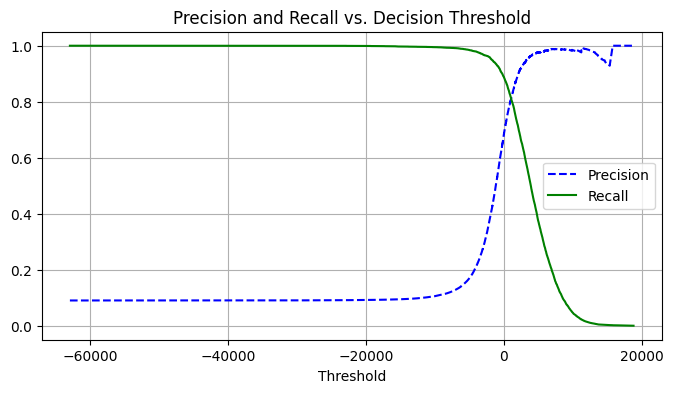

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import precision_recall_curve

# Load and prepare the data
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target
X_train, y_train = X[:60000], y[:60000]
y_train_5 = (y_train == "5")

# Train classifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

# Compute scores
y_scores = sgd_clf.decision_function(X_train)
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

# Plotting
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.title("Precision and Recall vs. Decision Threshold")
plt.legend(loc="best")
plt.grid(True)
plt.show()


In [28]:
from sklearn.metrics import precision_score, recall_score

threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]
y_train_pred_90 = (y_scores >= threshold_90_precision)



In [29]:
precision_score(y_train_5, y_train_pred_90)


0.9000705384434516

In [30]:
recall_score(y_train_5, y_train_pred_90)

0.7061427780852241

In [31]:
from sklearn.metrics import roc_curve
fpr,tpr,threshlods= roc_curve(y_train_5,y_scores)

<ipython-input-32-595e141700c3>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


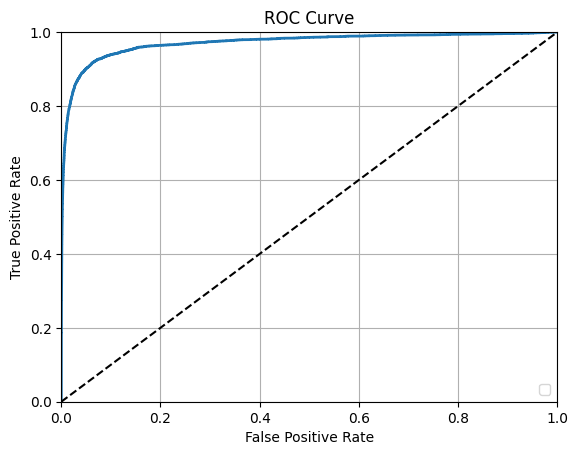

In [32]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')  # Dashed diagonal
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
plot_roc_curve(fpr,tpr)
plt.show()

In [33]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_scores)

np.float64(0.9709618248430906)

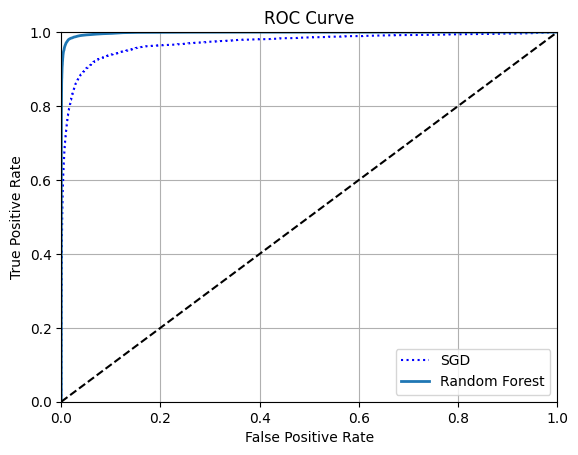

In [34]:
from sklearn.ensemble import RandomForestClassifier
forest_clf=RandomForestClassifier(random_state=42)
y_probas_forest=cross_val_predict(forest_clf,X_train,y_train_5, cv=3, method="predict_proba")

y_scores_forest=y_probas_forest[:,1]
fpr_forest,tpr_forest,thresholds_forest=roc_curve(y_train_5,y_scores_forest)
plt.plot(fpr,tpr,"b:",label="SGD")
plot_roc_curve(fpr_forest,tpr_forest,"Random Forest")
plt.legend(loc="lower right")
plt.show()

In [35]:
roc_auc_score(y_train_5,y_scores_forest)

np.float64(0.9983436731328145)

In [36]:
sgd_clf.fit(X_train,y_train)
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

In [37]:
some_digit_scores=sgd_clf.decision_function([some_digit])
some_digit_scores

array([[-31893.03095419, -34419.69069632,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])

In [38]:
np.argmax(some_digit_scores)

np.int64(3)

In [39]:
sgd_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='<U1')

In [40]:
sgd_clf.classes_[5]

np.str_('5')

In [41]:
from sklearn.multiclass import OneVsOneClassifier
ovo_clf=OneVsOneClassifier(SGDClassifier(random_state=42))
ovo_clf.fit(X_train,y_train)
ovo_clf.predict([some_digit])

array(['5'], dtype=object)

In [42]:
len(ovo_clf.estimators_)

45

In [43]:
forest_clf.fit(X_train,y_train)
forest_clf.predict([some_digit])

array(['5'], dtype=object)

In [44]:
forest_clf.predict_proba([some_digit])

array([[0.  , 0.  , 0.01, 0.08, 0.  , 0.9 , 0.  , 0.  , 0.  , 0.01]])

In [45]:
cross_val_score(sgd_clf,X_train,y_train, cv=3,scoring="accuracy")

array([0.87365, 0.85835, 0.8689 ])

In [46]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled,y_train, cv=3, scoring="accuracy")

array([0.8983, 0.891 , 0.9018])

In [47]:
y_train_pred=cross_val_predict(sgd_clf,X_train_scaled,y_train,cv=3)
conf_mx=confusion_matrix(y_train,y_train_pred)
conf_mx

array([[5577,    0,   22,    5,    8,   43,   36,    6,  225,    1],
       [   0, 6400,   37,   24,    4,   44,    4,    7,  212,   10],
       [  27,   27, 5220,   92,   73,   27,   67,   36,  378,   11],
       [  22,   17,  117, 5227,    2,  203,   27,   40,  403,   73],
       [  12,   14,   41,    9, 5182,   12,   34,   27,  347,  164],
       [  27,   15,   30,  168,   53, 4444,   75,   14,  535,   60],
       [  30,   15,   42,    3,   44,   97, 5552,    3,  131,    1],
       [  21,   10,   51,   30,   49,   12,    3, 5684,  195,  210],
       [  17,   63,   48,   86,    3,  126,   25,   10, 5429,   44],
       [  25,   18,   30,   64,  118,   36,    1,  179,  371, 5107]])

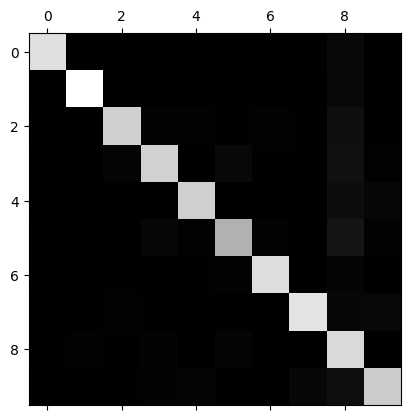

In [48]:
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

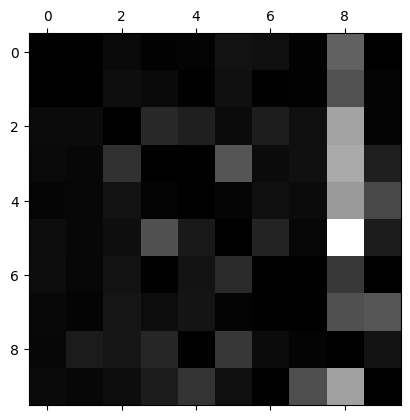

In [49]:
rows_sum=conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx=conf_mx/rows_sum
np.fill_diagonal(norm_conf_mx,0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.show()


In [52]:
import matplotlib.pyplot as plt
import numpy as np

def plot_digits(instances, images_per_row=10, **options):
    size = 28  # Each MNIST digit image is 28x28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size, size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    for row in range(n_rows):
        row_images.append(
            np.concatenate(images[row * images_per_row : (row + 1) * images_per_row], axis=1)
        )
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap=plt.cm.binary, **options)
    plt.axis("off")

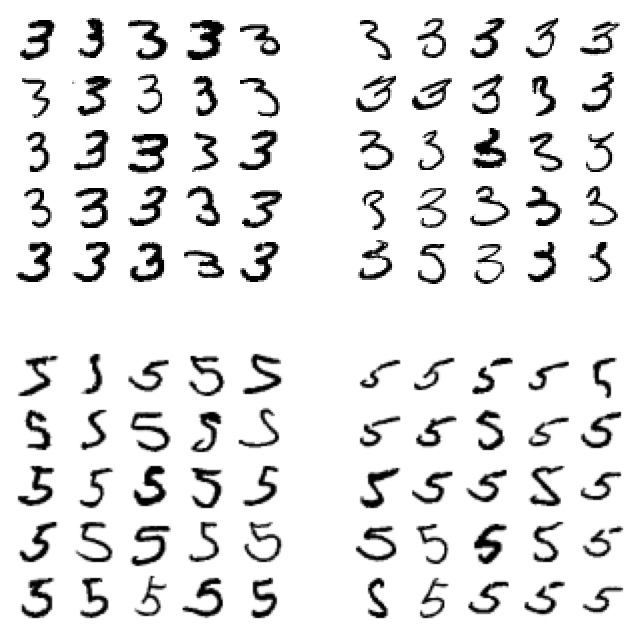

In [53]:
cl_a, cl_b = "3", "5"

X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

plt.figure(figsize=(8, 8))
plt.subplot(221); plot_digits(X_aa[:25], images_per_row=5)
plt.subplot(222); plot_digits(X_ab[:25], images_per_row=5)
plt.subplot(223); plot_digits(X_ba[:25], images_per_row=5)
plt.subplot(224); plot_digits(X_bb[:25], images_per_row=5)
plt.show()


Exercise Task

In [56]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np

#Loading MNIST
mnist=fetch_openml('mnist_784', version=1 , as_frame=False)
X,y=mnist['data'],mnist['target'].astype(np.uint8)

#Tain ,Test
X_Train,X_test,y_train,y_test=train_test_split(X,y,test_size=10000,random_state=42,stratify=y)

#Scaling the data
scalar=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

#Grid search for knn
param_grid={
    "n_neighbors":[3,4,5],
    "weights":["uniform","distance"]
}

knn_clf=KNeighborsClassifier()
grid_search=GridSearchCV(knn_clf,param_grid,cv=3,verbose=2,n_jobs=-1)

#Training data

grid_search.fit(X_train_scaled,y_train)

#Evaluate
best_knn=grid_search.best_estimator_
y_pred=best_knn.predict(X_test_scaled)
accuracy=accuracy_score(y_test,y_pred)

print("Best parameters:",grid_search.best_params_)
print("Test Accuracy:",accuracy)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'n_neighbors': 3, 'weights': 'uniform'}
Test Accuracy: 0.1034


**Image Rotation Fuction**

In [7]:
import numpy as np
def shift_image(image,direaction):
  image=image.reshape(28,28)
  shifted=np.zeros_like(image)

  if direction=="left":
    shifted[:,:-1]=image[:,1:]
  elif direction=="right":
    shifted[:,1:]=image[:,:-1]
  elif direction =="up":
    shifted[:-1,:]=image[1:,:]
  elif direction == "down":
    shifted[1:,:]=image[:-1,:]

  return shifted.reshape(784)

**Load and Preprocess Data**

In [3]:
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784',version=1,as_frame=False)
X,y=mnist["data"],mnist["target"].astype(np.uint8)


**Spliting Data**

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=10000,random_state=42,stratify=y)


**Creating images for data augmentation**





In [8]:
X_augmented=[]
y_augmented=[]

for image, label in zip(X_train,y_train):
  X_augmented.append(image)
  y_augmented.append(label)

for direction in ["left" , "right", "up","down"]:
   shifted_img=shift_image(image,direction)
   X_augmented.append(shifted_img)
   y_augmented.append(label)

X_augmented=np.array(X_augmented)
y_augmented=np.array(y_augmented)

**Scaling and training the model**

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

scaler=StandardScaler()
X_augmented_scaled= scaler.fit_transform(X_augmented)
X_test_scaled=scaler.transform(X_test)

knn=KNeighborsClassifier(n_neighbors=3, weights='distance')
knn.fit(X_augmented_scaled,y_augmented)
y_pred=knn.predict(X_test_scaled)
accuracy=accuracy_score(y_test,y_pred)
print("Test accuracy with data augmentation:",accuracy)

Test accuracy with data augmentation: 0.9485


In [12]:
from google.colab import files
uploaded=files.upload()

Saving 00001.1a31cc283af0060967a233d26548a6ce to 00001.1a31cc283af0060967a233d26548a6ce
Saving 00002.5a587ae61666c5aa097c8e866aedcc59 to 00002.5a587ae61666c5aa097c8e866aedcc59
Saving 00003.19be8acd739ad589cd00d8425bac7115 to 00003.19be8acd739ad589cd00d8425bac7115
Saving 00004.b2ed6c3c62bbdfab7683d60e214d1445 to 00004.b2ed6c3c62bbdfab7683d60e214d1445
Saving 00005.07b9d4aa9e6c596440295a5170111392 to 00005.07b9d4aa9e6c596440295a5170111392
Saving 00006.654c4ec7c059531accf388a807064363 to 00006.654c4ec7c059531accf388a807064363
Saving 00007.2e086b13730b68a21ee715db145522b9 to 00007.2e086b13730b68a21ee715db145522b9


In [13]:
from google.colab import files
uploaded=files.upload()

Saving 00001.7848dde101aa985090474a91ec93fcf0 to 00001.7848dde101aa985090474a91ec93fcf0
Saving 00002.d94f1b97e48ed3b553b3508d116e6a09 to 00002.d94f1b97e48ed3b553b3508d116e6a09
Saving 00003.2ee33bc6eacdb11f38d052c44819ba6c to 00003.2ee33bc6eacdb11f38d052c44819ba6c
Saving 00004.eac8de8d759b7e74154f142194282724 to 00004.eac8de8d759b7e74154f142194282724
Saving 00005.57696a39d7d84318ce497886896bf90d to 00005.57696a39d7d84318ce497886896bf90d
Saving 00006.5ab5620d3d7c6c0db76234556a16f6c1 to 00006.5ab5620d3d7c6c0db76234556a16f6c1
Saving 00007.d8521faf753ff9ee989122f6816f87d7 to 00007.d8521faf753ff9ee989122f6816f87d7
Saving 00008.dfd941deb10f5eed78b1594b131c9266 to 00008.dfd941deb10f5eed78b1594b131c9266


**Apache SpamAssassin's public**

In [15]:
import email
from email import policy
import os

# Load a single email from file
def load_email(filepath):
    with open(filepath, "rb") as f:
        return email.parser.BytesParser(policy=policy.default).parse(f)

# Get all uploaded files
uploaded_files = [f for f in os.listdir() if os.path.isfile(f)]

# Manually separate ham and spam based on file naming or order
# Example: If first 5 files are ham, next 5 are spam:
ham_files = uploaded_files[:5]   # change as needed
spam_files = uploaded_files[5:]  # change as needed

# Load emails
ham_emails = [load_email(f) for f in ham_files]
spam_emails = [load_email(f) for f in spam_files]


**Train and test sets**

In [16]:
from sklearn.model_selection import train_test_split

all_emails=ham_emails+spam_emails
all_labels=[0] * len(ham_emails) + [1] * len(spam_emails)

X_train_raw,X_test_raw,y_train,y_test=train_test_split(
    all_emails,all_labels, test_size=0.2, random_state=42
)

**Converting Emails to plain text**

In [21]:
def email_to_text(email_obj):
    if email_obj.is_multipart():
        parts = []
        for part in email_obj.walk():
            content_type = part.get_content_type()
            content_disposition = str(part.get("Content-Disposition"))

            if content_type == "text/plain" and "attachment" not in content_disposition:
                payload = part.get_payload(decode=True)
                if payload:
                    try:
                        parts.append(payload.decode(errors="ignore"))
                    except:
                        continue
        return "\n".join(parts)
    else:
        payload = email_obj.get_payload(decode=True)
        if payload:
            return payload.decode(errors="ignore")
        return str(email_obj.get_payload())


In [22]:
X_train = [email_to_text(email) for email in X_train_raw]
X_test = [email_to_text(email) for email in X_test_raw]


**Vectorixzing text using  TfidVectorizer**

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer=TfidfVectorizer()
X_train_vectorized=vectorizer.fit_transform(X_train)
X_test_vectorized=vectorizer.transform(X_test)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

clf=LogisticRegression(max_iter=1000)
clf.fit(X_train_vectorized,y_train)

y_pred=clf.predict(X_test_vectorized)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
